<a href="https://colab.research.google.com/github/frenchMontajes/thesis-web-app/blob/main/ThesisVerificationV6_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Cell 1: Mount Google Drive - RUN

In [ ]:
# ── Cell 1: Mount Google Drive ──
from google.colab import drive
drive.mount('/content/drive')

# ── Set working directory ──
import os
os.chdir('/content/drive/MyDrive/ThesisVerifcation')
print(os.getcwd())

Mounted at /content/drive
/content/drive/MyDrive/ThesisVerifcation


#  Cell 2: Libraries - RUN

In [ ]:
!pip install torch torchvision --quiet
!pip install scikit-learn opencv-python matplotlib --quiet
!pip install torchinfo --quiet

# Cell 3: Imports - RUN




In [ ]:
# ── Cell 3: Imports ──
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchinfo import summary
import numpy as np
import os
import cv2
import random
import math
import json
from PIL import Image
from sklearn.metrics import (
    roc_auc_score, accuracy_score,
    precision_score, recall_score,
    f1_score, roc_curve
)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import combinations

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
# Should print: Device: cuda  ✅
# If cpu → Runtime → Change runtime type → T4 GPU

Device: cuda


# Cell 4: Extract H5 File

In [ ]:
import h5py

H5_PATH = "/content/drive/MyDrive/ThesisVerifcation/pre-process_images.h5"

def remap_h5_paths(h5_path, local_root, colab_root):
    with h5py.File(h5_path, "a") as hf:
        old_paths = [
            p.decode("utf-8") if isinstance(p, bytes) else p
            for p in hf["paths"]
        ]
        new_paths = []
        for p in old_paths:
            p = p.replace("\\", "/")           # fix backslashes
            p = p.replace(local_root, colab_root)  # replace root

            # ── Fix double /content//content/ if it happened ──
            p = p.replace("/content//content/", "/content/")

            new_paths.append(p)

        del hf["paths"]
        dt = h5py.special_dtype(vlen=str)
        hf.create_dataset("paths", data=new_paths, dtype=dt)

    print("✅ Paths remapped!")
    print(f"   Sample: {new_paths[0]}")

# ── Run again to fix the doubled paths ──
remap_h5_paths(
    h5_path    = H5_PATH,
    local_root = "pre-process_images",  # ← current broken root
    colab_root = "/content/pre-process_images"   # ← same, just fixes doubles
)

✅ Paths remapped!
   Sample: /content//content/pre-process_images/Dataset 1/forgeries/writer_01/forgeries_1_1.png


#  Cell 5: Copy H5 to Colab local disk (faster training)

In [ ]:
import shutil
import os

LOCAL_H5 = "/content/pre-process_images.h5"

if not os.path.exists(LOCAL_H5):
    print("Copying H5 to local disk...")
    shutil.copy(H5_PATH, LOCAL_H5)
    print("✅ Copied!")
else:
    print("✅ Already on local disk.")

H5_PATH = LOCAL_H5  # use local path from here on

Copying H5 to local disk...
✅ Copied!


# Cell 6: Build path_to_idx from H5

In [ ]:
import h5py

def load_path_to_idx(h5_path):
    with h5py.File(h5_path, "r") as hf:
        paths = [
            p.decode("utf-8") if isinstance(p, bytes) else p
            for p in hf["paths"]
        ]
    return {p: i for i, p in enumerate(paths)}

# ── Reload ──
path_to_idx = load_path_to_idx(H5_PATH)

# ── Verify ──
sample = list(path_to_idx.keys())[0]
print(f"Sample key: '{sample}'")
print(f"Type: {type(sample)}")

Sample key: '/content//content/pre-process_images/Dataset 1/forgeries/writer_01/forgeries_1_1.png'
Type: <class 'str'>


In [ ]:
# # 1️⃣ Install unrar (needed to extract .rar files)
# !apt-get install unrar -y

# # 2️⃣ Define paths
# rar_file = '/content/drive/MyDrive/ThesisVerifcation/pre-process_images.rar'     # your .rar file
# extract_folder = '/content' # folder to extract contents

# # 3️⃣ Make sure the extraction folder exists
# import os
# os.makedirs(extract_folder, exist_ok=True)

# # 4️⃣ Extract the .rar file
# !unrar x "{rar_file}" "{extract_folder}/"

# Datasets

1. Dataset 1 Images CEDAR 55 Writers - 24 Genuine x 24 Forge
2. Dataset 2 Images Self Made 47 Writiers - 50 Genuine x 20 Forge
3. Dataset 3 UTSig - 100 Writers - 27 Genuine x 36 Forge

# Cell 7: Total Datasets (Pre-Processed)

In [ ]:
import h5py
from pathlib import Path

def count_signatures_from_h5(h5_path):
    dataset_counts = {}

    with h5py.File(h5_path, "r") as hf:
        paths = [
            p.decode("utf-8") if isinstance(p, bytes) else p
            for p in hf["paths"]
        ]

    for p in paths:
        lower_path = p.lower()
        parts = Path(p).parts

        # ── Detect label ──
        label = None
        if any(x in lower_path for x in ['forg', 'forge', 'forged', 'forgery', 'full_forg', 'forgeries']):
            label = 'forged'
        elif any(x in lower_path for x in ['real', 'org', 'original', 'full_org', 'real', 'genuine']):
            label = 'genuine'
        else:
            continue

        if label is None:
            continue

        # ── Detect dataset ──
        key = None
        for part in parts:
            part_lower = part.lower()
            if 'dataset 1' in part_lower:
                key = 'Dataset 1'
            elif 'dataset 2' in part_lower:
                key = 'Dataset 2'
            elif 'dataset 3' in part_lower:
                key = 'Dataset 3'


        if key is None:
            continue

        if key not in dataset_counts:
            dataset_counts[key] = {'forged': 0, 'genuine': 0}

        dataset_counts[key][label] += 1

    return dataset_counts


# ── Run ──
counts = count_signatures_from_h5(H5_PATH)

print("=" * 52)
print(f"{'Dataset':<25} {'Forged':>10} {'Genuine':>10} {'Total':>10}")
print("=" * 52)

total_forged  = 0
total_genuine = 0

for dataset, c in sorted(counts.items()):
    forged  = c['forged']
    genuine = c['genuine']
    total_forged  += forged
    total_genuine += genuine
    print(f"{dataset:<25} {forged:>10} {genuine:>10} {forged + genuine:>10}")

print("=" * 52)
print(f"{'GRAND TOTAL':<25} {total_forged:>10} {total_genuine:>10} {total_forged + total_genuine:>10}")
print("=" * 52)

Dataset                       Forged    Genuine      Total
Dataset 1                       1320       1320       2640
Dataset 2                        940       2350       3290
Dataset 3                       3600       2700       6300
GRAND TOTAL                     5860       6370      12230


# Cell 8: Split Logic - RUN

In [ ]:
import h5py
import random
from collections import defaultdict

def split_persons(persons, train=0.70, val=0.15):
    persons   = list(persons)
    random.shuffle(persons)
    train_end = int(train * len(persons))
    val_end   = train_end + int(val * len(persons))
    train_w   = persons[:train_end]
    val_w     = persons[train_end:val_end]
    test_w    = persons[val_end:]
    return train_w, val_w, test_w


def create_shared_splits(h5_path):
    # ── Load all paths from H5 ──
    with h5py.File(h5_path, "r") as hf:
        all_paths = [
            p.decode("utf-8") if isinstance(p, bytes) else p
            for p in hf["paths"]
        ]

    # ── Group paths by dataset → label → writer ──
    # mirrors your exact folder structure per dataset
    ds1_real    = defaultdict(list)  # orignal/        → person → [paths]
    ds1_forged  = defaultdict(list)  # forgeries/      → person → [paths]
    ds2_genuine = defaultdict(list)  # Genuine/    → person → [paths]
    ds2_forged  = defaultdict(list)  # Forge/       → person → [paths]
    ds3_genuine = defaultdict(list)  # Genuine/     → person → [paths]
    ds3_forged  = defaultdict(list)  # Forgery/       → person → [paths]

    for p in all_paths:
        parts     = p.replace("\\", "/").split("/")
        p_lower   = p.lower()
        parts_low = [x.lower() for x in parts]

        # ── Dataset 1 ── structure: Dataset 1 Images CEDAR/original|forgeries/person/img
        if any('dataset 1' in x for x in parts_low):
            writer = parts[-2]
            if 'original' in parts_low:
                ds1_real[writer].append(p)
            elif 'forgeries' in parts_low:
                ds1_forged[writer].append(p)

        # ── Dataset 2 ── structure: Dataset 2 Images Self-Made/Genuine|Forge/person/img
        elif any('dataset 2' in x for x in parts_low):
            writer = parts[-2]
            if 'genuine' in parts_low:
                ds2_genuine[writer].append(p)
            elif 'forge' in parts_low:
                ds2_forged[writer].append(p)

        # ── Dataset 3 ── structure: Dataset 3 Images UTSig/Genuine|Forgery/writer/img
        elif any('dataset 3' in x for x in parts_low):
            writer = parts[-2]
            if 'genuine' in parts_low:
                ds3_genuine[writer].append(p)
            elif 'forgery' in parts_low:
                ds3_forged[writer].append(p)

    splits = {}

    # ── Dataset 1 ──────────────────────────────────────────────────────────
    if ds1_real and ds1_forged:
        data1 = sorted(ds1_real.keys())
        train_p, val_p, test_p = split_persons(data1)
        splits["dataset1"] = {
            "train"         : train_p,
            "val"           : val_p,
            "test"          : test_p,
            "genuine_paths" : dict(ds1_real),
            "forged_paths"  : dict(ds1_forged),
        }
        print(f"Dataset 1 → Writers: {len(data1)} | "
              f"Train: {len(train_p)} | Val: {len(val_p)} | Test: {len(test_p)}")
    else:
        print("Dataset 1 → Not found, skipping.")

    # ── Dataset 2 ──────────────────────────────────────────────────────────
    if ds2_genuine and ds2_forged:
        data2 = sorted(ds2_genuine.keys())
        train_p2, val_p2, test_p2 = split_persons(data2)
        splits["dataset2"] = {
            "train"        : train_p2,
            "val"          : val_p2,
            "test"         : test_p2,
            "genuine_paths": dict(ds2_genuine),
            "forged_paths" : dict(ds2_forged),
        }
        print(f"Dataset 2 → Writers: {len(data2)} | "
              f"Train: {len(train_p2)} | Val: {len(val_p2)} | Test: {len(test_p2)}")
    else:
        print("Dataset 2 → Not found, skipping.")

    # ── Dataset 3 ──────────────────────────────────────────────────────────
    if ds3_genuine and ds3_forged:
        data3 = sorted(ds3_genuine.keys())
        train_p3, val_p3, test_p3 = split_persons(data3)
        splits["dataset3"] = {
            "train"        : train_p3,
            "val"          : val_p3,
            "test"         : test_p3,
            "genuine_paths": dict(ds3_genuine),
            "forged_paths" : dict(ds3_forged),
        }
        print(f"Dataset 3 → Writers: {len(data3)} | "
              f"Train: {len(train_p3)} | Val: {len(val_p3)} | Test: {len(test_p3)}")
    else:
        print("Dataset 3 → Not found, skipping.")

    return splits


# ── Run ──
SHARED_SPLITS = create_shared_splits(H5_PATH)

Dataset 1 → Writers: 55 | Train: 38 | Val: 8 | Test: 9
Dataset 2 → Writers: 47 | Train: 32 | Val: 7 | Test: 8
Dataset 3 → Writers: 100 | Train: 70 | Val: 15 | Test: 15


# Cell 9: Augmentation

In [ ]:
import h5py
from PIL import Image
from torch.utils.data import Dataset
import torch
import torchvision.transforms as transforms


class SignatureDataset(Dataset):
    def __init__(self, pairs, h5_path, path_to_idx, augment=False):
        self.pairs = pairs
        self.h5_path = h5_path
        self.path_to_idx = path_to_idx
        self.augment = augment

        # IMPORTANT: Do not open file here
        self.h5_file = None

        # Base transform (no augmentation)
        self.base_transform = transforms.Compose([ # Val/Test
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

        # Augmentation transform
        self.aug_transform = transforms.Compose([
            transforms.RandomRotation(7),
            transforms.RandomAffine(
                degrees=0,
                translate=(0.03, 0.03),
                scale=(0.95, 1.05),
                shear=3
            ),
            transforms.ColorJitter(brightness=0.1, contrast=0.1),
            transforms.RandomApply([transforms.GaussianBlur(3)], p=0.1),
            transforms.ToTensor(),
            transforms.RandomErasing(p=0.1, scale=(0.01, 0.03), value=1.0),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

    def _get_h5(self):
        """
        Ensures each worker process opens its own HDF5 file handle.
        Safe for num_workers > 0.
        """
        if self.h5_file is None:
            self.h5_file = h5py.File(self.h5_path, "r")
        return self.h5_file

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        path_a, path_b, label = self.pairs[idx]

        # Decode bytes if needed
        if isinstance(path_a, bytes):
            path_a = path_a.decode("utf-8")
        if isinstance(path_b, bytes):
            path_b = path_b.decode("utf-8")

        hf = self._get_h5()

        idx_a = self.path_to_idx[path_a]
        idx_b = self.path_to_idx[path_b]

        # Load images from HDF5
        img_a = Image.fromarray(hf["images"][idx_a])
        img_b = Image.fromarray(hf["images"][idx_b])

        # Apply transforms
        if self.augment:
            img_a = self.aug_transform(img_a)
            img_b = self.aug_transform(img_b)
        else:
            img_a = self.base_transform(img_a)
            img_b = self.base_transform(img_b)

        return img_a, img_b, torch.tensor(label, dtype=torch.float32)

    def __del__(self):
        # Clean up file handle (per worker)
        if self.h5_file is not None:
            try:
                self.h5_file.close()
            except Exception:
                pass

# Cell 10: Making Pair Images

In [ ]:
from itertools import combinations
import random

def make_pairs_from_images(genuine_imgs, forged_imgs):
    """
    Create pairs for a single writer.

    Returns:
        - genuine_pairs: (img1, img2, label=1)  → 1 = genuine
        - forged_pairs: (img1, img2, label=0)   → 0 = forged
    """
    genuine_pairs, forged_pairs = [], []

    # Positive pairs: genuine vs genuine
    for a, b in combinations(genuine_imgs, 2):
        genuine_pairs.append((a, b, 1))  # label=1 for genuine

    # Negative pairs: genuine vs forged
    for g in genuine_imgs:
        for f in forged_imgs:
            forged_pairs.append((g, f, 0))   # label=0 for forged

    return genuine_pairs, forged_pairs


def make_cross_writer_pairs(genuine_dict, person_list):
    """
    Create cross-writer negative pairs (genuine vs genuine from different writers)
    Returns list of tuples: (img1, img2, label=1)
    """
    cross_pairs = []
    persons = list(person_list)

    for i in range(len(persons)):
        p1 = persons[i]
        imgs1 = genuine_dict.get(p1, [])

        if not imgs1:
            continue

        for j in range(i + 1, len(persons)):
            p2 = persons[j]
            imgs2 = genuine_dict.get(p2, [])

            if not imgs2:
                continue

            # FULL combinations
            for img1 in imgs1:
                for img2 in imgs2:
                    cross_pairs.append((img1, img2, 0))  # label=0 for forged/different writer

    return cross_pairs

def build_all_pairs(shared_splits, balance=True):
    all_train_genuine, all_train_forged = [], []
    all_val_genuine, all_val_forged = [], []
    all_test_genuine, all_test_forged = [], []

  # ── Dataset 1 ──────────────────────────────────────────────────────────
    if "dataset1" in shared_splits:
        ds1 = shared_splits["dataset1"]

        for split, person_list in [
            ("train", ds1["train"]),
            ("val",   ds1["val"]),
            ("test",  ds1["test"]),
        ]:
            genuine_pairs, forged_pairs = [], []
            for person in person_list:
                genuine_imgs = ds1["genuine_paths"].get(person, [])
                forged_imgs = ds1["forged_paths"].get(person, [])
                if not genuine_imgs or not forged_imgs:
                    continue
                gp, fp = make_pairs_from_images(genuine_imgs, forged_imgs)
                genuine_pairs.extend(gp)
                forged_pairs.extend(fp)

            # ✅ NEW PART
            cross_pairs = make_cross_writer_pairs(ds1["genuine_paths"], person_list)
            forged_pairs.extend(cross_pairs)

            if split == "train":
                all_train_genuine.extend(genuine_pairs)
                all_train_forged.extend(forged_pairs)
            elif split == "val":
                all_val_genuine.extend(genuine_pairs)
                all_val_forged.extend(forged_pairs)
            else:
                all_test_genuine.extend(genuine_pairs)
                all_test_forged.extend(forged_pairs)

        print(f"Dataset 1 → Train/Val/Test pairs ✅")

    # ── Dataset 2 ──────────────────────────────────────────────────────────
    if "dataset2" in shared_splits:
        ds2 = shared_splits["dataset2"]

        for split, person_list in [
            ("train", ds2["train"]),
            ("val",   ds2["val"]),
            ("test",  ds2["test"]),
        ]:
            genuine_pairs, forged_pairs = [], []
            for person in person_list:
                genuine_imgs = ds2["genuine_paths"].get(person, [])
                forged_imgs  = ds2["forged_paths"].get(person,  [])
                if not genuine_imgs or not forged_imgs:
                    continue
                gp, fp = make_pairs_from_images(genuine_imgs, forged_imgs)
                genuine_pairs.extend(gp)
                forged_pairs.extend(fp)

            # Cross-writer negatives (genuine vs genuine, different writers)
            cross_pairs = make_cross_writer_pairs(ds2["genuine_paths"], person_list)
            forged_pairs.extend(cross_pairs)

            if split == "train":
                all_train_genuine.extend(genuine_pairs)
                all_train_forged.extend(forged_pairs)
            elif split == "val":
                all_val_genuine.extend(genuine_pairs)
                all_val_forged.extend(forged_pairs)
            else:
                all_test_genuine.extend(genuine_pairs)
                all_test_forged.extend(forged_pairs)

        print(f"Dataset 2 → Train/Val/Test pairs ✅")

    # ── Dataset 3 ──────────────────────────────────────────────────────────
    if "dataset3" in shared_splits:
        ds3 = shared_splits["dataset3"]

        for split, writer_list in [
            ("train", ds3["train"]),
            ("val",   ds3["val"]),
            ("test",  ds3["test"]),
        ]:
            genuine_pairs, forged_pairs = [], []
            for writer in writer_list:
                genuine_imgs = ds3["genuine_paths"].get(writer, [])
                forged_imgs  = ds3["forged_paths"].get(writer,  [])
                if not genuine_imgs or not forged_imgs:
                    continue
                gp, fp = make_pairs_from_images(genuine_imgs, forged_imgs)
                genuine_pairs.extend(gp)
                forged_pairs.extend(fp)

            # Cross-writer negatives (genuine vs genuine, different writers)
            cross_pairs = make_cross_writer_pairs(ds3["genuine_paths"], writer_list)
            forged_pairs.extend(cross_pairs)

            if split == "train":
                all_train_genuine.extend(genuine_pairs)
                all_train_forged.extend(forged_pairs)
            elif split == "val":
                all_val_genuine.extend(genuine_pairs)
                all_val_forged.extend(forged_pairs)
            else:
                all_test_genuine.extend(genuine_pairs)
                all_test_forged.extend(forged_pairs)

        print(f"Dataset 3 → Train/Val/Test pairs ✅")

    # ── Balance and shuffle (exactly same as your original) ────────────────
    def balance_and_shuffle(genuine, forged, label=""):
        if balance:
            n       = min(len(genuine), len(forged))
            genuine = random.sample(genuine, n)
            forged  = random.sample(forged,  n)
        pairs = genuine + forged
        random.shuffle(pairs)
        pos = sum(1 for _, _, l in pairs if l == 1)  # genuine
        neg = sum(1 for _, _, l in pairs if l == 0)  # forged
        print(f"  {label:<16} {len(pairs):>8} pairs  "
              f"(genuine: {pos}, forged: {neg})")
        return pairs

    print("\nBalanced pair sets:")
    train_pairs = balance_and_shuffle(all_train_genuine, all_train_forged, "train")
    val_pairs   = balance_and_shuffle(all_val_genuine,   all_val_forged,   "val")
    test_pairs  = balance_and_shuffle(all_test_genuine,  all_test_forged,  "test")

    print("=" * 50)
    print(f"Train Pairs  : {len(train_pairs)}")
    print(f"Val Pairs    : {len(val_pairs)}")
    print(f"Test Pairs   : {len(test_pairs)}")
    print("=" * 50)
    return train_pairs, val_pairs, test_pairs


# ── Run ──

train_pairs, val_pairs, test_pairs = build_all_pairs(SHARED_SPLITS)

# ── Datasets ──────────────────────────────────────────────────────────────────
# 32 64 128 256
BATCH_SIZE = 128

train_dataset = SignatureDataset(train_pairs, H5_PATH, path_to_idx, augment=True)
val_dataset   = SignatureDataset(val_pairs,   H5_PATH, path_to_idx, augment=False)
test_dataset  = SignatureDataset(test_pairs,  H5_PATH, path_to_idx, augment=False)

# ── Worker Seed Function ───────────────────────────────────────────────────────
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

# ── Generator ─────────────────────────────────────────────────────────────────
g = torch.Generator()
g.manual_seed(SEED)

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_loader = DataLoader(
    train_dataset,
    batch_size        = BATCH_SIZE,
    shuffle           = True,
    num_workers       = 2,
    pin_memory        = True,
    persistent_workers= True,
    prefetch_factor   = 2,
    worker_init_fn    = seed_worker,
    generator         = g
)
val_loader = DataLoader(
    val_dataset,
    batch_size        = BATCH_SIZE,
    shuffle           = False,
    num_workers       = 2,
    pin_memory        = True,
    persistent_workers= True,
    prefetch_factor   = 2,
    worker_init_fn    = seed_worker
)
test_loader = DataLoader(
    test_dataset,
    batch_size        = BATCH_SIZE,
    shuffle           = False,
    num_workers       = 2,
    pin_memory        = True,
    persistent_workers= True,
    prefetch_factor   = 2,
    worker_init_fn    = seed_worker
)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Dataset 1 → Train/Val/Test pairs ✅
Dataset 2 → Train/Val/Test pairs ✅
Dataset 3 → Train/Val/Test pairs ✅

Balanced pair sets:
  train              148516 pairs  (genuine: 74258, forged: 74258)
  val                 29646 pairs  (genuine: 14823, forged: 14823)
  test                35098 pairs  (genuine: 17549, forged: 17549)
Train Pairs  : 148516
Val Pairs    : 29646
Test Pairs   : 35098
Train batches : 1161
Val batches   : 232
Test batches  : 275


# Cell 11: Metrics

In [ ]:
# ── Metrics Cell (Euclidean Distance) ──
import numpy as np
from sklearn.metrics import (
    roc_auc_score, accuracy_score,
    precision_score, recall_score,
    f1_score, roc_curve
)

def compute_metrics(labels, distances, threshold=None):
    """
    labels     : (0 = Forged, 1 = Genuine)
    distances  : Euclidean distances (LOW = Genuine,  HIGH = Forged)
    """

    labels = np.array(labels)
    distances = np.array(distances)

    # ─────────────────────────────
    # Convert Euclidean distance to similarity score
    # ─────────────────────────────
    # Euclidean distance interpretation:
    #   LOW distance  → more similar → Genuine (positive class)
    #   HIGH distance → less similar → Forged (negative class)
    #
    # Since sklearn ROC/AUC assumes:
    #   HIGH score = more likely positive class,
    # we invert the distance.
    scores = -distances


    # ─────────────────────────────
    # AUC (Area Under ROC Curve)
    # ─────────────────────────────
    # Measures overall separability between Genuine and Forged classes.
    auc = roc_auc_score(labels, scores)


    # ─────────────────────────────────────────
    # ROC Curve computation
    # ─────────────────────────────────────────
    # fpr = False Positive Rate (Forged classified as Genuine)
    # tpr = True Positive Rate (Genuine correctly classified)
    # fnr = False Negative Rate = 1 - tpr
    fpr, tpr, roc_thresholds = roc_curve(labels, scores)
    fnr = 1 - tpr


    # ─────────────────────────────────────────
    # Equal Error Rate (EER)
    # ─────────────────────────────────────────
    # EER is the point where:
    #   False Acceptance Rate (FAR) ≈ False Rejection Rate (FRR)
    # We approximate it by finding the threshold where FPR and FNR are closest.
    eer_idx       = np.argmin(np.abs(fpr - fnr))
    eer           = (fpr[eer_idx] + fnr[eer_idx]) / 2
    eer_threshold = roc_thresholds[eer_idx]



    # ─────────────────────────────────────────
    # Best threshold (EER-based decision threshold)
    # ─────────────────────────────────────────
    # If no threshold is provided, we use the EER operating point.
    if threshold is None:
        threshold = eer_threshold


    # ─────────────────────────────────────────
    # Binary classification predictions
    # ─────────────────────────────────────────
    # Since higher score = more likely Genuine:
    #   score >= threshold → Genuine (1)
    #   score <  threshold → Forged (0)
    preds = (scores >= threshold).astype(int)


    # ─────────────────────────────────────────
    # Standard classification metrics
    # ─────────────────────────────────────────
    acc  = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, zero_division=0)
    rec  = recall_score(labels, preds, zero_division=0)
    f1   = f1_score(labels, preds, zero_division=0)


    # ─────────────────────────────
    # FAR / FRR computation
    # ─────────────────────────────
    # Confusion matrix interpretation:
    #   TN = Forged correctly rejected
    #   FP = Forged incorrectly accepted (False Accept)
    #   FN = Genuine incorrectly rejected (False Reject)
    #   TP = Genuine correctly accepted

    tn = np.sum((labels == 0) & (preds == 0))
    fp = np.sum((labels == 0) & (preds == 1))
    fn = np.sum((labels == 1) & (preds == 0))
    tp = np.sum((labels == 1) & (preds == 1))

    # False Acceptance Rate: Forged accepted as Genuine
    far = fp / (fp + tn + 1e-8)

    # False Rejection Rate: Genuine rejected as Forged
    frr = fn / (fn + tp + 1e-8)

    return {
        "auc": auc,
        "eer": eer,
        "threshold": threshold,

        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "far": far,
        "frr": frr,

        "fpr": fpr,
        "tpr": tpr,
        "fnr": fnr,
        "roc_thresholds": roc_thresholds
    }

# Cell 11: DCNN Backbone (Feature Extraction)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class DeepCNN(nn.Module):
    def __init__(self):
        super(DeepCNN, self).__init__()

        self.features = nn.Sequential(
            # Stack 1
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Stack 2
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Stack 3
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Stack 4
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),

            # Stack 5
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.5),

        )

        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # Embedding head
        self.embedding = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),

        )

    def forward(self, x):
        x = self.features(x)        # [B, 256, H, W]
        x = self.gap(x)             # [B, 256, 1, 1]
        x = torch.flatten(x, 1)     # [B, 256]
        x = self.embedding(x)       # [B, 128]

        # Normalize embeddings
        x = F.normalize(x, p=2, dim=1)

        return x

# Cell 12: Siamese Neural Network

In [ ]:
# Siamese Network
class SiameseNetwork(nn.Module):
    def __init__(self, backbone):
        super(SiameseNetwork, self).__init__()
        self.backbone = backbone

    def forward(self, x1, x2):
        emb_a = self.backbone(x1)
        emb_b = self.backbone(x2)
        dist = F.pairwise_distance(emb_a, emb_b)
        return dist, emb_a, emb_b


# Contrastive Loss
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, emb_a, emb_b, label):
        # Euclidean distance
        distance = F.pairwise_distance(emb_a, emb_b)

      # label = 1 means genuine pair
      # label = 0 means forged pair
        loss = torch.mean(
            label * torch.pow(distance, 2) +
            (1 - label) * torch.pow(torch.clamp(self.margin - distance, min=0.0), 2)
        )
        return loss

# -----------------------------
# Initialize model
# -----------------------------
def init_weights(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
        nn.init.ones_(m.weight)
        nn.init.zeros_(m.bias)
    elif isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

backbone = DeepCNN().to(device)
siamese = SiameseNetwork(backbone).to(device)
siamese.apply(init_weights)

# -----------------------------
# Sanity check
# -----------------------------
siamese.eval()          # ← add this
with torch.no_grad():
    img_a = torch.randn(1, 1, 155, 220).to(device)
    img_b = torch.randn(1, 1, 155, 220).to(device)
    dist, emb_a, emb_b = siamese(img_a, img_b)

print(f"Image A shape  : {img_a.shape}")
print(f"Embedding A    : {emb_a.shape}")
print(f"Embedding B    : {emb_b.shape}")
print(f"Distance shape : {dist.shape}")
print(f"Euclidean distances: {dist}")
print(f"\nEmb A norms    : {emb_a.norm(dim=1)}")
print(f"Emb B norms    : {emb_b.norm(dim=1)}")

total = sum(p.numel() for p in siamese.parameters())
print(f"\nTotal params   : {total:,}")
print("✅ SiameseNetwork ready!")

siamese.train()         # ← switch back for training
summary(siamese, input_data=(img_a, img_b), verbose=0)

Image A shape  : torch.Size([1, 1, 155, 220])
Embedding A    : torch.Size([1, 128])
Embedding B    : torch.Size([1, 128])
Distance shape : torch.Size([1])
Euclidean distances: tensor([0.0294], device='cuda:0')

Emb A norms    : tensor([1.0000], device='cuda:0')
Emb B norms    : tensor([1.], device='cuda:0')

Total params   : 492,000
✅ SiameseNetwork ready!


Layer (type:depth-idx)                   Output Shape              Param #
SiameseNetwork                           [1]                       --
├─DeepCNN: 1-1                           [1, 128]                  --
│    └─Sequential: 2-1                   [1, 256, 4, 6]            --
│    │    └─Conv2d: 3-1                  [1, 16, 155, 220]         160
│    │    └─BatchNorm2d: 3-2             [1, 16, 155, 220]         32
│    │    └─ReLU: 3-3                    [1, 16, 155, 220]         --
│    │    └─MaxPool2d: 3-4               [1, 16, 77, 110]          --
│    │    └─Conv2d: 3-5                  [1, 32, 77, 110]          4,640
│    │    └─BatchNorm2d: 3-6             [1, 32, 77, 110]          64
│    │    └─ReLU: 3-7                    [1, 32, 77, 110]          --
│    │    └─MaxPool2d: 3-8               [1, 32, 38, 55]           --
│    │    └─Conv2d: 3-9                  [1, 64, 38, 55]           18,496
│    │    └─BatchNorm2d: 3-10            [1, 64, 38, 55]           128
│    │

In [ ]:
# Check if Dataset 4 paths exist in H5 at all
ds2_paths = [p for p in path_to_idx.keys() if 'Dataset 2' in p]
print(f"Dataset 2 paths in H5: {len(ds2_paths)}")

if ds2_paths:
    print(f"Sample DS2 path: '{ds2_paths[0]}'")
else:
    print("❌ No Dataset 2 paths found in H5!")

# Also check what datasets ARE in H5
for ds in ['Dataset 1', 'Dataset 2', 'Dataset 3']:
    count = sum(1 for p in path_to_idx.keys() if ds in p)
    print(f"{ds}: {count} paths in H5")

Dataset 2 paths in H5: 3290
Sample DS2 path: '/content/pre-process_images/Dataset 2/Forge/01/DSC00101.JPG'
Dataset 1: 2640 paths in H5
Dataset 2: 3290 paths in H5
Dataset 3: 6300 paths in H5


In [ ]:
for i, layer in enumerate(siamese.backbone.features):
    print(i, layer)

NameError: name 'siamese' is not defined

# Cell 13: Warm Up Cosine - RUN

In [ ]:
import math
import torch

def warmup_cosine_scheduler(
    optimizer,
    warmup_epochs,
    total_epochs,
    min_lr,
    base_lr
):
    def lr_lambda(epoch):
        # Warmup phase
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs

        # Cosine decay phase
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)

        cosine_decay = 0.5 * (1 + math.cos(math.pi * progress))

        min_lr_ratio = min_lr / base_lr

        return min_lr_ratio + (1 - min_lr_ratio) * cosine_decay

    return torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda
    )

# Cell 14: Training Loop For Siamese - DO NOT RUN THIS

In [ ]:
# Train Cell
import os
import json
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve
import time

SIAMESE_DIR            = "/content/drive/MyDrive/ThesisVerifcation/siamese_models"
SIAMESE_CHECKPOINT_DIR = "/content/drive/MyDrive/ThesisVerifcation/siamese_checkpoints"
os.makedirs(SIAMESE_DIR,            exist_ok=True)
os.makedirs(SIAMESE_CHECKPOINT_DIR, exist_ok=True)

# ── Hyperparameters ───────────────────────────────────────────────────────────
EPOCHS_SIAMESE     = 50
PATIENCE_SIAMESE   = 10
WARMUP_SIAMESE     = 5
# ACCUMULATION_STEPS = 2
MAX_GRAD_NORM      = 1.0
LEARNING_RATE      = 3e-4

# ── Loss + Optimizer ──────────────────────────────────────────────────────────
criterion_siamese = ContrastiveLoss(margin=0.5)

optimizer_siamese = torch.optim.AdamW(
    siamese.parameters(),
    lr           = LEARNING_RATE,
    weight_decay = 1e-2,
    eps = 1e-8
)

# ── Scheduler ─────────────────────────────────────────────────────────────────
scheduler_siamese = warmup_cosine_scheduler(
    optimizer_siamese,
    warmup_epochs = WARMUP_SIAMESE,
    total_epochs  = EPOCHS_SIAMESE,
    min_lr        = 1e-7,
    base_lr       = LEARNING_RATE
)

# ── History ───────────────────────────────────────────────────────────────────
history_siamese = {
    'train_loss': [],
    'val_loss'  : [],
    'val_auc'   : [],


}

best_val_auc_siamese = 0.0
patience_count       = 0
save_path_siamese    = None
scaler               = torch.amp.GradScaler()

print("=" * 60)
print("Training Siamese Network)")
print("=" * 60)

total_start_time = time.time()


for epoch in range(EPOCHS_SIAMESE):
    epoch_start_time = time.time()

    # ── Train ──────────────────────────────────────────────────────────────
    siamese.train()
    train_loss = 0.0
    optimizer_siamese.zero_grad(set_to_none=True)

    for i, (img_a, img_b, labels) in enumerate(train_loader):
        img_a  = img_a.to(device,  non_blocking=True)
        img_b  = img_b.to(device,  non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.amp.autocast(device_type='cuda'):
            dist, emb_a, emb_b = siamese(img_a, img_b)

            hard_mask = (
                ((labels == 0) & (dist < 1.0)) |
                ((labels == 1) & (dist > 0.5))
            )
            loss = criterion_siamese(emb_a, emb_b, labels)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer_siamese)
        torch.nn.utils.clip_grad_norm_(siamese.parameters(), MAX_GRAD_NORM)

        scaler.step(optimizer_siamese)
        scaler.update()

        optimizer_siamese.zero_grad(set_to_none=True)

        train_loss += loss.item()



    # ── Validate ───────────────────────────────────────────────────────────
    siamese.eval()
    val_loss = 0.0

    val_scores = []
    val_labels_list = []

    with torch.no_grad():
        for img_a, img_b, labels in val_loader:
            img_a = img_a.to(device, non_blocking=True)
            img_b = img_b.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True).float()

            with torch.amp.autocast(device_type=device.type):
                dist, emb_a, emb_b = siamese(img_a, img_b)
                loss = criterion_siamese(emb_a, emb_b, labels)

            val_loss += loss.item()

            # STORE RESULTS (IMPORTANT)
            val_scores.extend(dist.cpu().numpy().flatten())
            val_labels_list.extend(labels.cpu().numpy().flatten())

    # Convert
    val_scores_arr = np.array(val_scores)
    val_labels_arr = np.array(val_labels_list)

    avg_val_loss = val_loss / len(val_loader)

    # Metrics
    val_metrics = compute_metrics(val_labels_arr, val_scores_arr)
    val_auc = val_metrics["auc"]

    # ── Epoch metrics & Elapsed Time ───────────────────────────────────────────────────────

    avg_train_loss = train_loss / len(train_loader)
    current_lr = optimizer_siamese.param_groups[0]['lr']
    elapsed_time = time.time() - epoch_start_time

    print(f"⏱ Epoch {epoch+1:03d}/{EPOCHS_SIAMESE} elapsed: {elapsed_time:.1f} sec")

    # ── Scheduler step ─────────────────────────────────────────────────────
    scheduler_siamese.step()

    # ── History ────────────────────────────────────────────────────────────
    history_siamese['train_loss'].append(avg_train_loss)
    history_siamese['val_loss'].append(avg_val_loss)
    history_siamese['val_auc'].append(float(val_auc))



    # ── Checkpoint every 10 epochs ─────────────────────────────────────────
    if (epoch + 1) % 10 == 0:
        checkpoint_path = os.path.join(
            SIAMESE_CHECKPOINT_DIR,
            f"siamese_checkpoint_epoch{epoch+1}.pth"
        )
        torch.save({
            'epoch'           : epoch,
            'model_state_dict': siamese.state_dict(),
            'optimizer_state' : optimizer_siamese.state_dict(),
            'val_auc'         : val_auc,
            'history'         : history_siamese
        }, checkpoint_path)
        print(f"💾 Checkpoint saved: {checkpoint_path}")

    # ── Early stopping + save on AUC ───────────────────────────────────────
    if val_auc > best_val_auc_siamese:
        best_val_auc_siamese = val_auc

        if save_path_siamese and os.path.exists(save_path_siamese):
            os.remove(save_path_siamese)

        save_path_siamese = os.path.join(
            SIAMESE_DIR,
            f"siamese_auc{val_auc:.4f}.pth"
        )
        torch.save(siamese.state_dict(), save_path_siamese)

        patience_count = 0
        print(f"Epoch {epoch+1:03d}/{EPOCHS_SIAMESE} → "
              f"Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | "
              f"AUC: {val_auc:.4f} | "
              f"LR: {current_lr:.2e} ✅ saved")
    else:
        patience_count += 1
        print(f"Epoch {epoch+1:03d}/{EPOCHS_SIAMESE} → "
              f"Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | "
              f"AUC: {val_auc:.4f} | "
              f"LR: {current_lr:.2e} "
              f"patience {patience_count}/{PATIENCE_SIAMESE}")
        if patience_count >= PATIENCE_SIAMESE:
            print(f"\n⚠️ Early stopping at epoch {epoch+1}")
            break

# ── Save history ───────────────────────────────────────────────────────────────
history_path = os.path.join(SIAMESE_DIR, "t2_siamese_history.json")
with open(history_path, "w") as f:
    json.dump(history_siamese, f)
print(f"\n✅ History saved: {history_path}")

# ── Restore best weights ───────────────────────────────────────────────────────
if save_path_siamese and os.path.exists(save_path_siamese):
    print("=" * 60)
    try:
        siamese.load_state_dict(
            torch.load(
                save_path_siamese,
                map_location = device,
                weights_only = True
            )
        )
    except TypeError:
        siamese.load_state_dict(
            torch.load(save_path_siamese, map_location=device)
        )
    print(f"✅ Best model loaded: {os.path.basename(save_path_siamese)}")
    print(f"   Best Val AUC : {best_val_auc_siamese:.4f}")
    print("=" * 60)
else:
    print("=" * 60)
    print("❌ No saved weights found!")
    print("=" * 60)

Training Siamese Network)
⏱ Epoch 001/50 elapsed: 754.3 sec
Epoch 001/50 → Loss: 0.0812 | Val Loss: 0.0975 | AUC: 0.8417 | LR: 6.00e-05 ✅ saved
⏱ Epoch 002/50 elapsed: 756.9 sec
Epoch 002/50 → Loss: 0.0261 | Val Loss: 0.0765 | AUC: 0.8415 | LR: 1.20e-04 patience 1/10
⏱ Epoch 003/50 elapsed: 760.6 sec
Epoch 003/50 → Loss: 0.0223 | Val Loss: 0.0510 | AUC: 0.8815 | LR: 1.80e-04 ✅ saved
⏱ Epoch 004/50 elapsed: 751.9 sec
Epoch 004/50 → Loss: 0.0162 | Val Loss: 0.0388 | AUC: 0.8931 | LR: 2.40e-04 ✅ saved
⏱ Epoch 005/50 elapsed: 750.3 sec
Epoch 005/50 → Loss: 0.0143 | Val Loss: 0.0406 | AUC: 0.8974 | LR: 3.00e-04 ✅ saved
⏱ Epoch 006/50 elapsed: 749.2 sec
Epoch 006/50 → Loss: 0.0132 | Val Loss: 0.0386 | AUC: 0.9068 | LR: 3.00e-04 ✅ saved
⏱ Epoch 007/50 elapsed: 752.4 sec
Epoch 007/50 → Loss: 0.0119 | Val Loss: 0.0352 | AUC: 0.9171 | LR: 3.00e-04 ✅ saved
⏱ Epoch 008/50 elapsed: 755.1 sec
Epoch 008/50 → Loss: 0.0111 | Val Loss: 0.0353 | AUC: 0.9081 | LR: 2.99e-04 patience 1/10
⏱ Epoch 009/50 ela

# Cell 15: Plot Metrics -

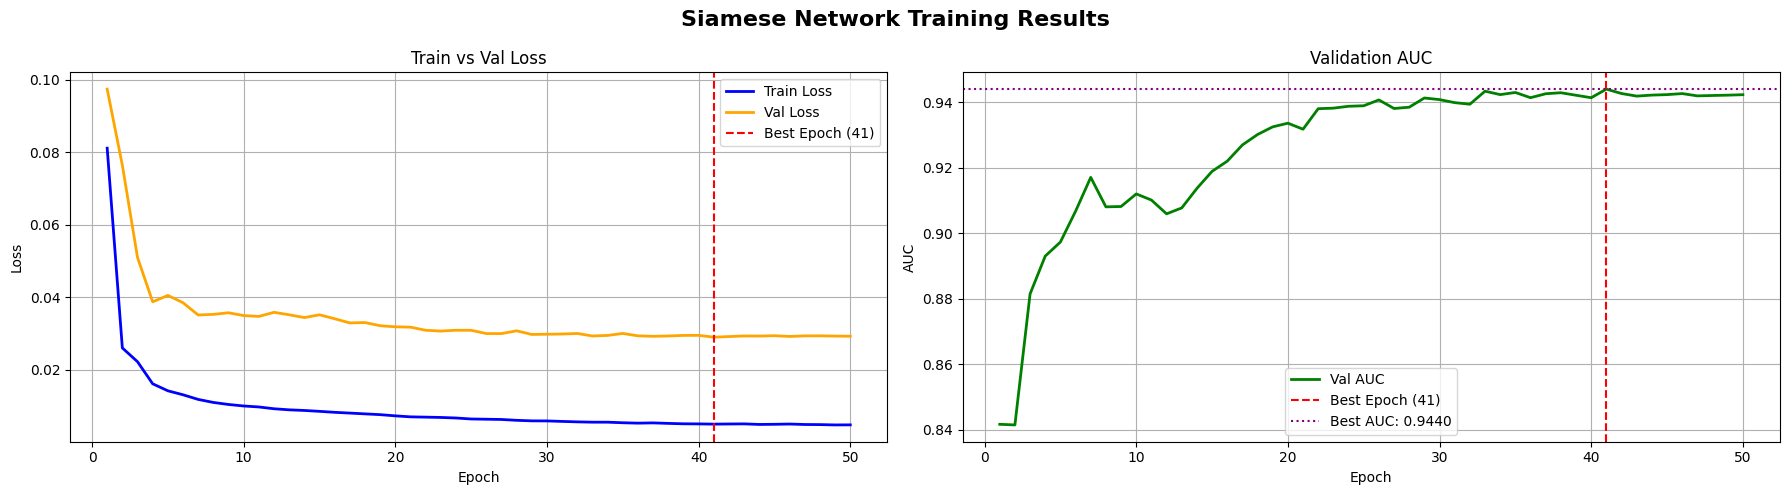

✅ Plot saved as warmpup_dcnn_training_results.png


In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(history_siamese['train_loss']) + 1))

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Siamese Network Training Results',
             fontsize=16, fontweight='bold')

best_epoch = history_siamese['val_auc'].index(max(history_siamese['val_auc'])) + 1

# Plot 1 — MODEL LOSS
axes[0].plot(epochs, history_siamese['train_loss'], label='Train Loss', color='blue',   linewidth=2)
axes[0].plot(epochs, history_siamese['val_loss'],   label='Val Loss',   color='orange', linewidth=2)
axes[0].axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Epoch ({best_epoch})')
axes[0].set_title('Train vs Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Plot 2 — MODEL AUC
axes[1].plot(epochs, history_siamese['val_auc'], label='Val AUC', color='green', linewidth=2)
axes[1].axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Epoch ({best_epoch})')
axes[1].axhline(y=max(history_siamese['val_auc']), color='purple', linestyle=':',
                label=f'Best AUC: {max(history_siamese["val_auc"]):.4f}')
axes[1].set_title('Validation AUC')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('t4-warmpup_dcnn_training_results.png', dpi=150)
plt.show()
print("✅ Plot saved as warmpup_dcnn_training_results.png")

# Cell 16: Validation - RUN

In [ ]:
# ── Validation ──

# ── Load best model ──
if save_path_siamese and os.path.exists(save_path_siamese):
    try:
        siamese.load_state_dict(
            torch.load(save_path_siamese, map_location=device, weights_only=True)
        )
    except TypeError:
        siamese.load_state_dict(
            torch.load(save_path_siamese, map_location=device)
        )

    print(f"✅ Loaded: {os.path.basename(save_path_siamese)}")
    print(f"   Best Val AUC: {best_val_auc_siamese:.4f}")
else:
    print("❌ No saved weights found!")


# ── Evaluation ──
siamese.eval()

val_scores = []
val_labels = []

with torch.no_grad():
    for img_a, img_b, labels in val_loader:
        img_a = img_a.to(device)
        img_b = img_b.to(device)
        labels = labels.to(device).float()

        # Forward pass
        distances, _, _ = siamese(img_a, img_b)


        val_scores.extend(distances.cpu().numpy().flatten())
        val_labels.extend(labels.cpu().numpy().flatten())


# ── Convert to numpy ──
val_scores = np.array(val_scores)
val_labels = np.array(val_labels)

# ── Compute metrics ──
val_metrics = compute_metrics(val_labels, val_scores)

val_auc = val_metrics["auc"]
val_eer = val_metrics["eer"]
best_val_threshold = val_metrics["threshold"]

print("="*60)
print("Validation (Euclidean Distance)")
print("="*60)
print(f"AUC : {val_auc:.4f}")
print(f"EER : {val_eer*100:.2f}%")
print(f"Threshold : {best_val_threshold:.4f}")
print(f"Accuracy : {val_metrics['accuracy']*100:.2f}%")
print(f"FAR : {val_metrics['far']*100:.2f}%")
print(f"FRR : {val_metrics['frr']*100:.2f}%")
print("="*60)

✅ Loaded: siamese_auc0.9440.pth
   Best Val AUC: 0.9440
Validation (Euclidean Distance)
AUC : 0.9440
EER : 12.64%
Threshold : -0.2284
Accuracy : 87.36%
FAR : 12.64%
FRR : 12.64%


In [ ]:
# val_scores_arr is raw distances — no conversion needed
genuine_dists = val_scores_arr[val_labels_arr == 1]
forged_dists  = val_scores_arr[val_labels_arr == 0]

print(f"Genuine → mean: {genuine_dists.mean():.3f} | std: {genuine_dists.std():.3f}")
print(f"Forged  → mean: {forged_dists.mean():.3f} | std: {forged_dists.std():.3f}")
print(f"Gap     : {forged_dists.mean() - genuine_dists.mean():.3f}")

Genuine → mean: 0.160 | std: 0.061
Forged  → mean: 0.368 | std: 0.110
Gap     : 0.208


# Cell 18: Test Eval Function

In [ ]:
# ── Test / Final Evaluation ──

def final_evaluation_siamese(model, loader, device, threshold=None):
    model.eval()
    all_scores, all_labels = [], []

    with torch.no_grad():
        for img_a, img_b, labels in loader:
            img_a  = img_a.to(device)
            img_b  = img_b.to(device)
            labels = labels.to(device).float()

            distances, _, _ = model(img_a, img_b)

            all_scores.extend(distances.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy().flatten())

    scores = np.array(all_scores)
    labels = np.array(all_labels)

    # Compute metrics
    metrics = compute_metrics(labels, scores, threshold=threshold)

    print("=" * 60)
    print("Siamese Network → Final Test Evaluation")
    print("=" * 60)
    print(f"Threshold  : {metrics['threshold']:.4f}")
    print(f"AUC        : {metrics['auc']:.4f}")
    print(f"EER        : {metrics['eer']*100:.2f}%")
    print(f"FAR        : {metrics['far']*100:.2f}%")
    print(f"FRR        : {metrics['frr']*100:.2f}%")
    print(f"Accuracy   : {metrics['accuracy']*100:.2f}%")
    print("=" * 60)

    # ── Plot ──
    fpr = metrics['fpr']
    tpr = metrics['tpr']
    fnr = metrics['fnr']
    thresholds_plot = metrics['roc_thresholds']

    # ✅ Replace with — use the EER values directly from metrics
    eer_point_fpr = metrics['eer']   # since at EER, FAR ≈ FRR ≈ EER
    eer_point_tpr = 1 - metrics['eer']


    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Siamese Network — Evaluation", fontsize=14, fontweight='bold')

    # ROC
    axes[0].plot(fpr, tpr, lw=2, label=f"AUC = {metrics['auc']:.4f}")
    axes[0].plot([0, 1], [0, 1], 'k--')
    axes[0].scatter(eer_point_fpr, eer_point_tpr, s=80,
                    label=f"EER = {metrics['eer']*100:.2f}%")
    axes[0].set_title("ROC Curve")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # FAR / FRR
    axes[1].plot(thresholds_plot, fpr*100, label='FAR')
    axes[1].plot(thresholds_plot, fnr*100, label='FRR')
    axes[1].axvline(x=metrics['threshold'], linestyle='--',
                    label=f"Threshold = {metrics['threshold']:.4f}")
    axes[1].set_title("FAR / FRR Curve")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


    return {
        "metrics": metrics,
        "labels": labels,
        "distances": scores
    }

# Cell 19: Test

Siamese Network → Final Test Evaluation
Threshold  : -0.2284
AUC        : 0.9599
EER        : 10.46%
FAR        : 11.74%
FRR        : 8.60%
Accuracy   : 89.83%


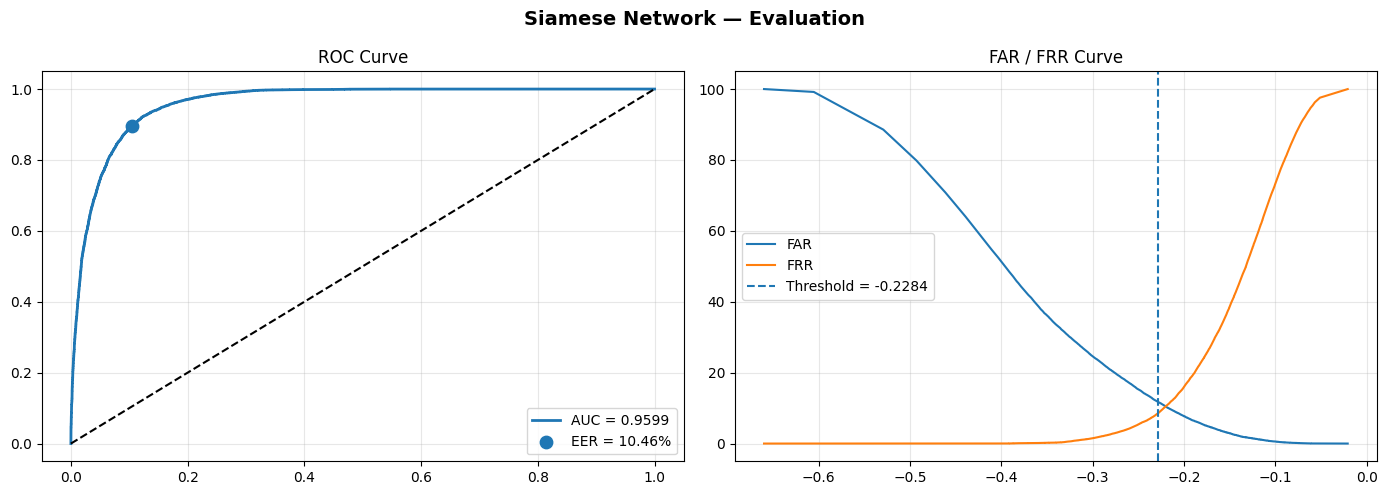

In [ ]:
test_result = final_evaluation_siamese(
    model=siamese,
    loader=test_loader,
    device=device,
    threshold=best_val_threshold
)

test_metrics   = test_result["metrics"]
test_labels    = test_result["labels"]
test_distances = test_result["distances"]

# Cell 19: Grad-CAM

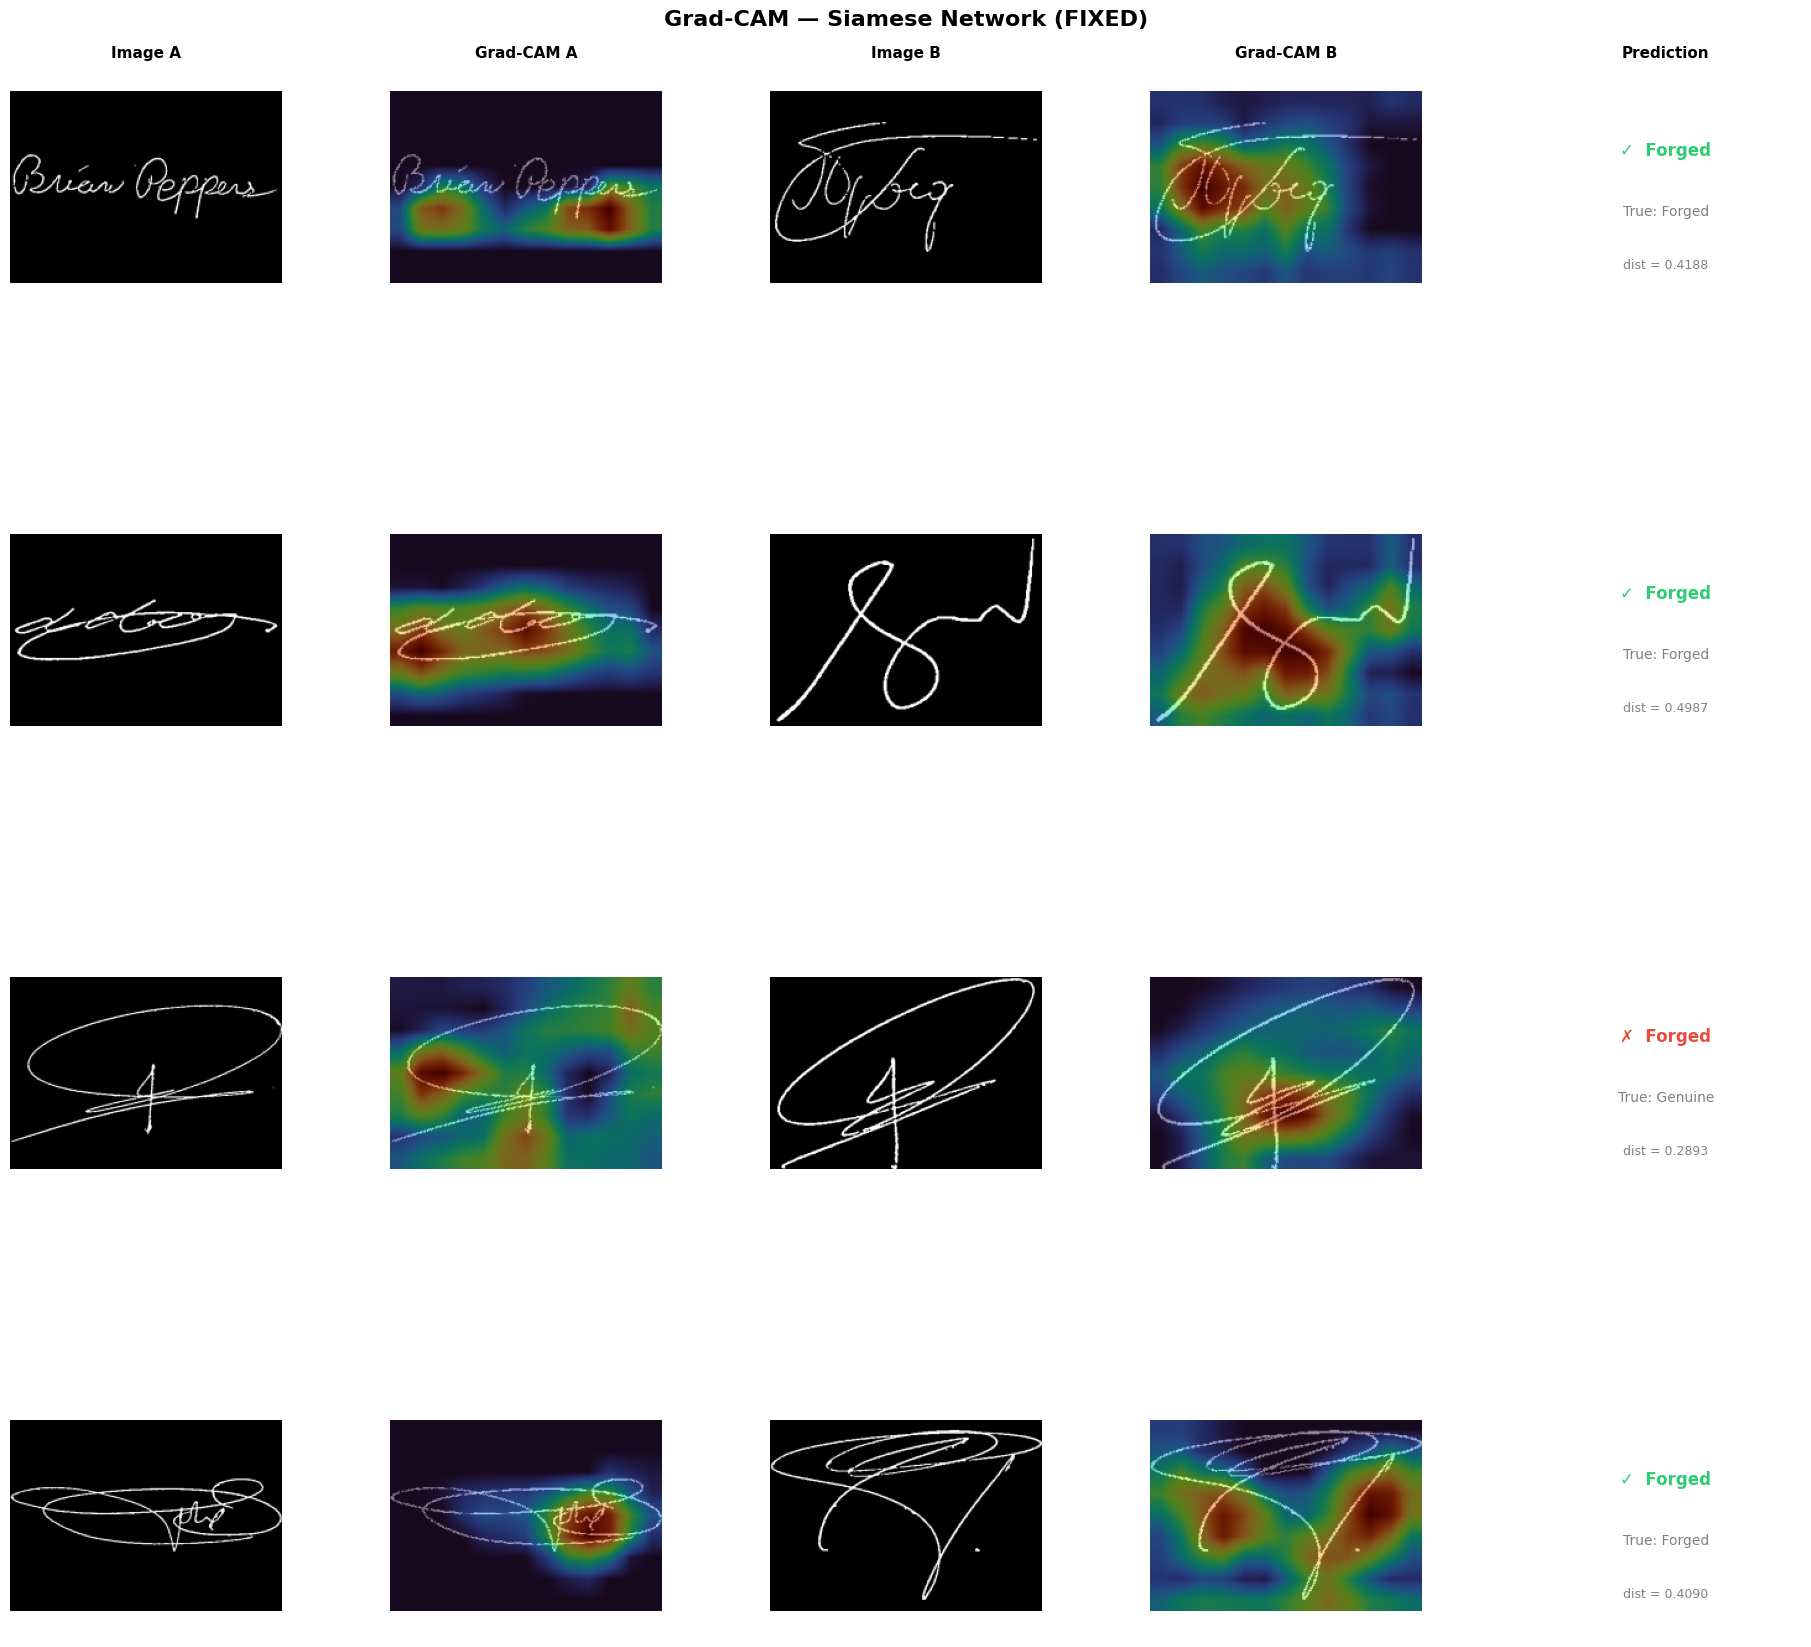

Saved: gradcam_pairs_fixed.png


In [ ]:
# ── Grad-CAM for Siamese Network (FIXED) ─────────────────────────────────────
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import torch
import torch.nn.functional as F


class GradCAM:
    """
    Pair-based Grad-CAM for Siamese Networks.
    Generates heatmaps for BOTH images using distance-based gradients.
    """
    def __init__(self, model: torch.nn.Module, target_layer: torch.nn.Module):
        self.model = model
        self.target_layer = target_layer
        self.gradients = []
        self.activations = []
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations.append(output)

        def backward_hook(module, grad_input, grad_output):
            self.gradients.append(grad_output[0])

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, img_a: torch.Tensor, img_b: torch.Tensor):
        """
        img_a, img_b : [1, 1, H, W]
        Returns      : heatmap_a, heatmap_b
        """

        self.model.eval()
        self.activations = []
        self.gradients = []

        img_a = img_a.requires_grad_(True)
        img_b = img_b.requires_grad_(True)

        # ── Forward pass ──
        emb_a = self.model.backbone(img_a)
        emb_b = self.model.backbone(img_b)

        # 🔥 KEY FIX: Use pairwise distance
        distance = F.pairwise_distance(emb_a, emb_b)

        # Use similarity signal
        score = -distance

        self.model.zero_grad()
        score.backward()

        # Extract activations and gradients
        act_a, act_b = self.activations
        grad_a, grad_b = self.gradients

        def compute_cam(activations, gradients):
            pooled_grads = gradients.mean(dim=[2, 3], keepdim=True)
            weighted = (pooled_grads * activations).sum(dim=1, keepdim=True)

            heatmap = weighted.squeeze().detach().cpu().numpy()

            # ReLU (disable for debugging if needed)
            heatmap = np.maximum(heatmap, 0)

            # Normalize
            if heatmap.max() > 0:
                heatmap = (heatmap - heatmap.min()) / (
                    heatmap.max() - heatmap.min() + 1e-8
                )

            return heatmap

        heatmap_a = compute_cam(act_a, grad_a)
        heatmap_b = compute_cam(act_b, grad_b)

        return heatmap_a, heatmap_b


# ── Overlay Function ─────────────────────────────────────────────
def overlay_gradcam(image_np: np.ndarray, heatmap: np.ndarray,
                    alpha: float = 0.5) -> np.ndarray:

    H, W = image_np.shape

    heatmap_resized = cv2.resize(heatmap, (W, H), interpolation=cv2.INTER_LINEAR)

    heatmap_colored = cv2.applyColorMap(
        (heatmap_resized * 255).astype(np.uint8),
        cv2.COLORMAP_TURBO   # better than JET
    )
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    image_rgb = (image_np * 255).astype(np.uint8)
    image_rgb = cv2.cvtColor(image_rgb, cv2.COLOR_GRAY2RGB)

    overlay = cv2.addWeighted(image_rgb, 1 - alpha, heatmap_colored, alpha, 0)
    return overlay


# ── Visualization ─────────────────────────────────────────────
def visualize_gradcam_pairs(siamese, test_loader, device,
                           threshold, n_pairs=6):

    # Target last conv layer (Stack 5)
    target_layer = siamese.backbone.features[17]

    gradcam = GradCAM(model=siamese, target_layer=target_layer)

    # ── Collect samples ──
    samples = []
    siamese.eval()

    with torch.no_grad():
        for img_a, img_b, labels in test_loader:
            for i in range(img_a.size(0)):
                samples.append((
                    img_a[i].unsqueeze(0),
                    img_b[i].unsqueeze(0),
                    labels[i].item()
                ))
                if len(samples) >= n_pairs:
                    break
            if len(samples) >= n_pairs:
                break

    # ── Plot ──
    fig = plt.figure(figsize=(18, n_pairs * 4), constrained_layout=True)
    gs  = gridspec.GridSpec(n_pairs, 5, figure=fig,
                            hspace=0.5, wspace=0.3)

    fig.suptitle("Grad-CAM — Siamese Network (FIXED)",
                 fontsize=16, fontweight='bold', y=1.02)

    col_titles = ["Image A", "Grad-CAM A", "Image B", "Grad-CAM B", "Prediction"]
    for col_idx, title in enumerate(col_titles):
        ax = fig.add_subplot(gs[0, col_idx])
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.axis('off')

    for row, (img_a, img_b, label) in enumerate(samples):

        img_a_dev = img_a.to(device)
        img_b_dev = img_b.to(device)

        # 🔥 KEY CHANGE: Pair-based Grad-CAM
        heatmap_a, heatmap_b = gradcam.generate(img_a_dev, img_b_dev)

        # Prediction
        with torch.no_grad():
            dist, _, _ = siamese(img_a_dev, img_b_dev)
            distance = dist.item()

        predicted_genuine = (distance <= -threshold)
        pred_label  = "Genuine" if predicted_genuine else "Forged"
        true_label  = "Genuine" if label == 1 else "Forged"
        is_correct  = (predicted_genuine == (label == 1))

        # Convert to numpy
        img_a_np = img_a.squeeze().cpu().numpy()
        img_b_np = img_b.squeeze().cpu().numpy()

        overlay_a = overlay_gradcam(img_a_np, heatmap_a)
        overlay_b = overlay_gradcam(img_b_np, heatmap_b)

        axes = [fig.add_subplot(gs[row, c]) for c in range(5)]

        axes[0].imshow(img_a_np, cmap='gray')
        axes[1].imshow(overlay_a)
        axes[2].imshow(img_b_np, cmap='gray')
        axes[3].imshow(overlay_b)

        for i in range(4):
            axes[i].axis('off')

        axes[4].axis('off')
        color  = '#2ecc71' if is_correct else '#e74c3c'
        status = '✓' if is_correct else '✗'

        axes[4].text(0.5, 0.65,
                     f"{status}  {pred_label}",
                     ha='center', va='center',
                     fontsize=12, fontweight='bold', color=color,
                     transform=axes[4].transAxes)

        axes[4].text(0.5, 0.40,
                     f"True: {true_label}",
                     ha='center', va='center',
                     fontsize=10, color='gray',
                     transform=axes[4].transAxes)

        axes[4].text(0.5, 0.18,
                     f"dist = {distance:.4f}",
                     ha='center', va='center',
                     fontsize=9, color='gray',
                     transform=axes[4].transAxes)


    plt.savefig("gradcam_pairs_fixed.png", dpi=150, bbox_inches='tight')
    plt.show()

    print("Saved: gradcam_pairs_fixed.png")


# ── Run ──
visualize_gradcam_pairs(
    siamese     = siamese,
    test_loader = test_loader,
    device      = device,
    threshold   = best_val_threshold,
    n_pairs     = 4
)

# Cell 20: Confusion Matrix

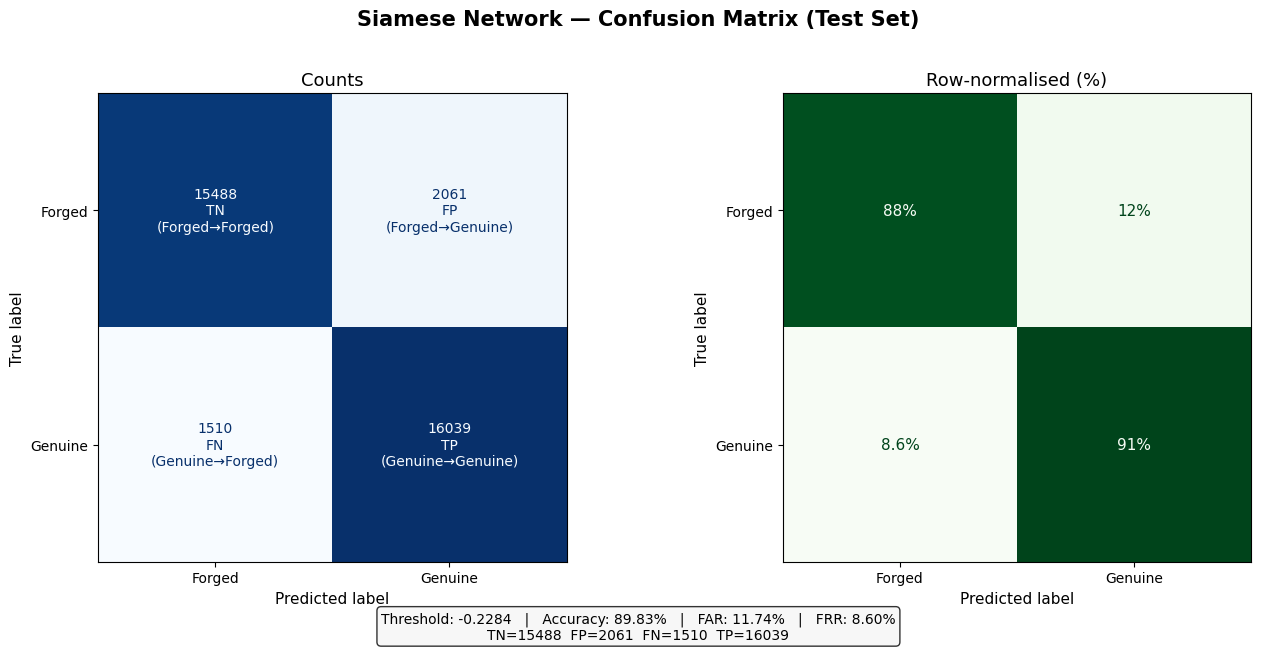

Saved: confusion_matrix.png


In [ ]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


def plot_confusion_matrix(labels, distances, threshold,
                          title="Siamese Network — Confusion Matrix",
                          save_path="confusion_matrix.png"):
    """
    labels    : ground-truth (0 = Forged, 1 = Genuine)
    distances : Euclidean distances from the model
    threshold : EER threshold (on the score space, i.e. best_val_threshold)
    """

    labels    = np.array(labels)
    distances = np.array(distances)
    scores    = -distances   # higher score = more likely Genuine

    # Binary predictions using EER threshold
    preds = (scores >= threshold).astype(int)

    # Confusion matrix  →  order: [Forged=0, Genuine=1]
    cm = confusion_matrix(labels, preds, labels=[0, 1])

    # ── Counts ──
    tn, fp, fn, tp = cm.ravel()

    # ── Rates ──
    far = fp / (fp + tn + 1e-8)   # Forged accepted as Genuine
    frr = fn / (fn + tp + 1e-8)   # Genuine rejected as Forged
    acc = (tp + tn) / len(labels)

    # ── Plot ──
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(title, fontsize=15, fontweight='bold', y=1.02)

    # ── Left: Raw count matrix ──
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Forged", "Genuine"]
    )
    disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title("Counts", fontsize=13)
    axes[0].set_xlabel("Predicted label", fontsize=11)
    axes[0].set_ylabel("True label", fontsize=11)

    # Annotate with TN / FP / FN / TP labels
    cell_labels = [
        ["TN\n(Forged→Forged)", "FP\n(Forged→Genuine)"],
        ["FN\n(Genuine→Forged)", "TP\n(Genuine→Genuine)"]
    ]
    for i in range(2):
        for j in range(2):
            axes[0].texts[i * 2 + j].set_text(
                f"{cm[i, j]}\n{cell_labels[i][j]}"
            )
            axes[0].texts[i * 2 + j].set_fontsize(10)

    # ── Right: Normalised (%) matrix ──
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    disp_norm = ConfusionMatrixDisplay(
        confusion_matrix=np.round(cm_norm, 1),
        display_labels=["Forged", "Genuine"]
    )
    disp_norm.plot(ax=axes[1], colorbar=False, cmap='Greens')
    axes[1].set_title("Row-normalised (%)", fontsize=13)
    axes[1].set_xlabel("Predicted label", fontsize=11)
    axes[1].set_ylabel("True label", fontsize=11)

    for text in axes[1].texts:
        val = text.get_text()
        text.set_text(f"{val}%")
        text.set_fontsize(11)

    # ── Metrics summary below the plots ──
    summary = (
        f"Threshold: {threshold:.4f}   |   "
        f"Accuracy: {acc*100:.2f}%   |   "
        f"FAR: {far*100:.2f}%   |   "
        f"FRR: {frr*100:.2f}%\n"
        f"TN={tn}  FP={fp}  FN={fn}  TP={tp}"
    )
    fig.text(0.5, -0.03, summary, ha='center', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='whitesmoke', alpha=0.8))

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")
    return cm


# ── Run on test set ──
cm = plot_confusion_matrix(
    labels    = test_labels,           # from final_evaluation_siamese()
    distances = test_distances,
    threshold = best_val_threshold,    # from validation
    title     = "Siamese Network — Confusion Matrix (Test Set)"
)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

backbone = DeepCNN()
model = SiameseNetwork(backbone).to(device)

model.load_state_dict(torch.load("/content/drive/MyDrive/ThesisVerifcation/siamese_models/siamese_auc0.9440.pth", map_location=device))

model.eval()

print(len(test_loader))

cuda
275


# Cell 21: Featured Map

Device: cuda
Hooks attached: 5 Conv layers
Input shape: torch.Size([1, 1, 155, 220])
Embedding shape: torch.Size([1, 128])
Feature maps captured: 5

🔍 Conv Layer 1


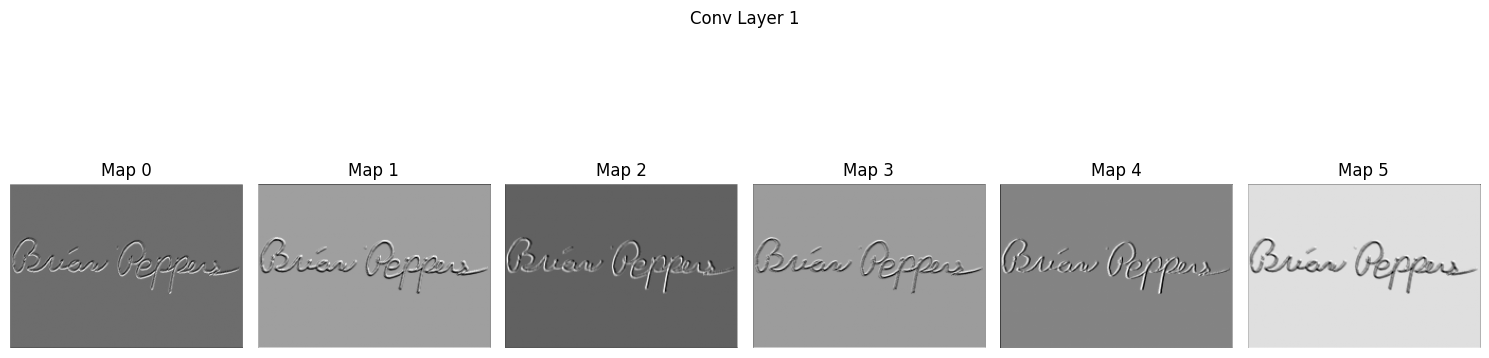


🔍 Conv Layer 2


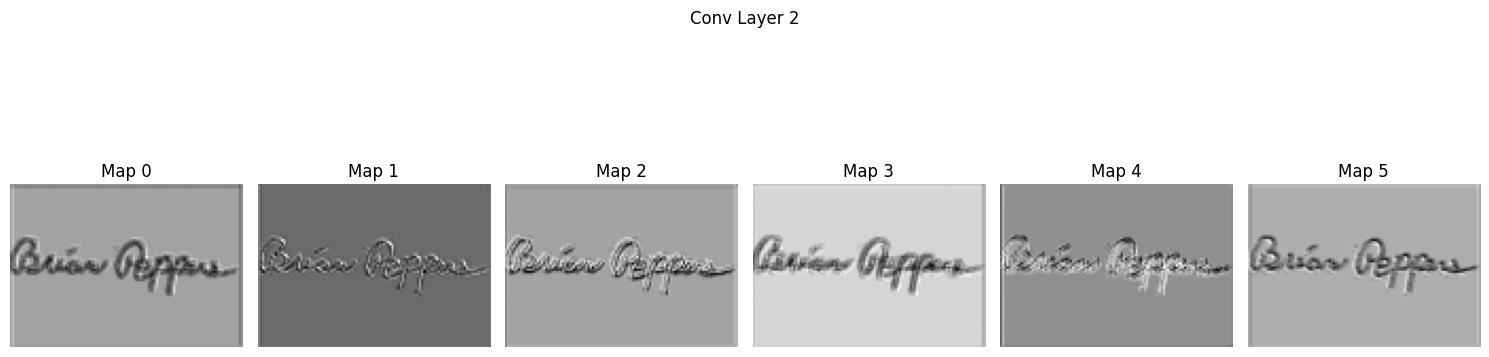


🔍 Conv Layer 3


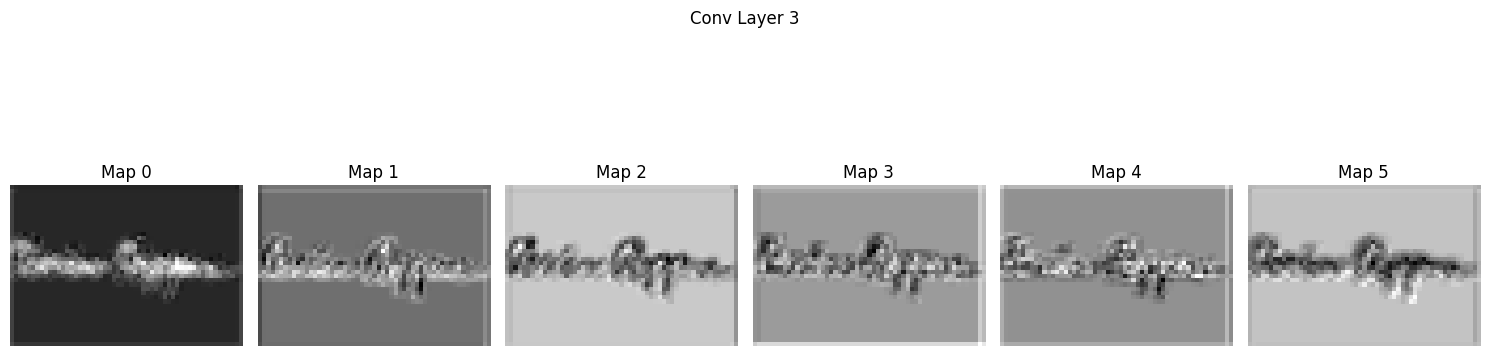


🔍 Conv Layer 4


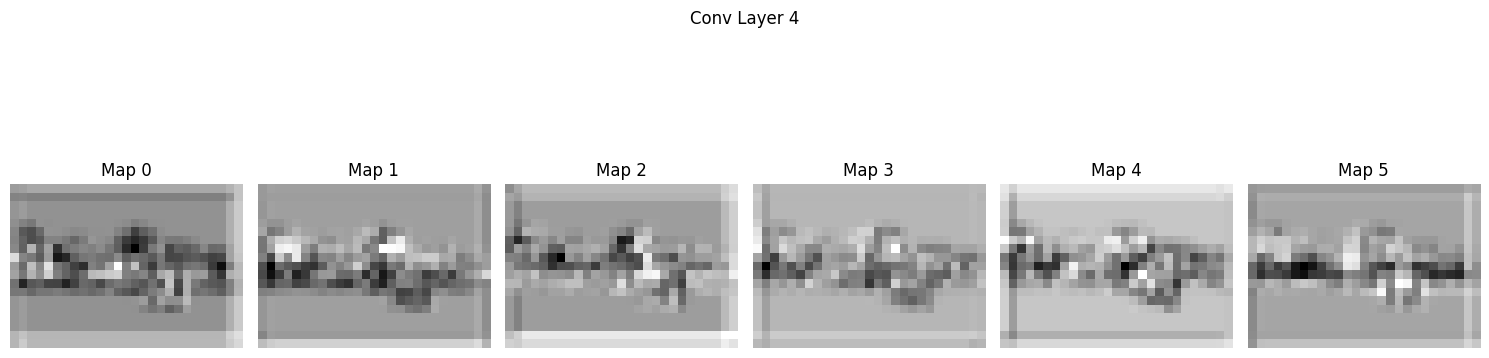


🔍 Conv Layer 5


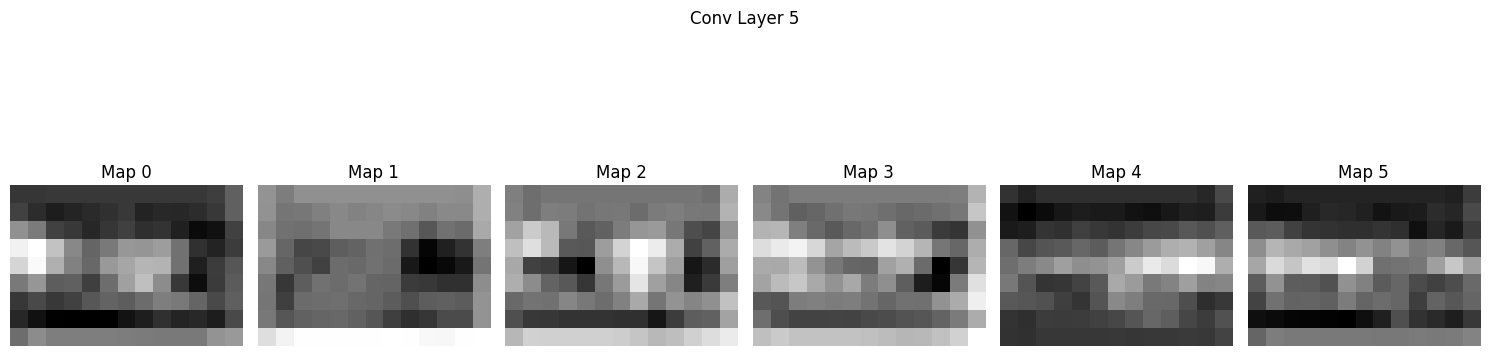

Hooks removed.


In [ ]:
import torch
import matplotlib.pyplot as plt

# =========================
# Set device + model
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

backbone = DeepCNN()
model = SiameseNetwork(backbone).to(device)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/ThesisVerifcation/siamese_models/siamese_auc0.9440.pth",
        map_location=device
    )
)

model.eval()

# =========================
# Hook setup
# =========================
feature_maps = []

def hook_fn(module, input, output):
    feature_maps.append(output.detach())

handles = []
for layer in model.backbone.features:
    if isinstance(layer, torch.nn.Conv2d):
        handles.append(layer.register_forward_hook(hook_fn))

print(f"Hooks attached: {len(handles)} Conv layers")

# =========================
# Get ONE Siamese batch correctly
# =========================
data_iter = iter(test_loader)
img1, img2, labels = next(data_iter)

# take ONE image from first pair
image = img1[0].unsqueeze(0).to(device)

print("Input shape:", image.shape)

# =========================
# Forward pass
# =========================
feature_maps.clear()

with torch.no_grad():
    embedding = model.backbone(image)

print("Embedding shape:", embedding.shape)
print("Feature maps captured:", len(feature_maps))

# =========================
# Visualization
# =========================
def visualize(feature_maps, layer_idx, num_maps=6):
    fmap = feature_maps[layer_idx].cpu()

    num_maps = min(num_maps, fmap.shape[1])

    fig, axes = plt.subplots(1, num_maps, figsize=(15, 5))

    for i in range(num_maps):
        axes[i].imshow(fmap[0, i], cmap='gray')
        axes[i].axis('off')
        axes[i].set_title(f"Map {i}")

    plt.suptitle(f"Conv Layer {layer_idx+1}")
    plt.tight_layout()
    plt.show()

for i in range(len(feature_maps)):
    print(f"\n🔍 Conv Layer {i+1}")
    visualize(feature_maps, i)

# =========================
# Cleanup hooks
# =========================
for h in handles:
    h.remove()

print("Hooks removed.")

# Cell 22: t-SNE + PCE Plot

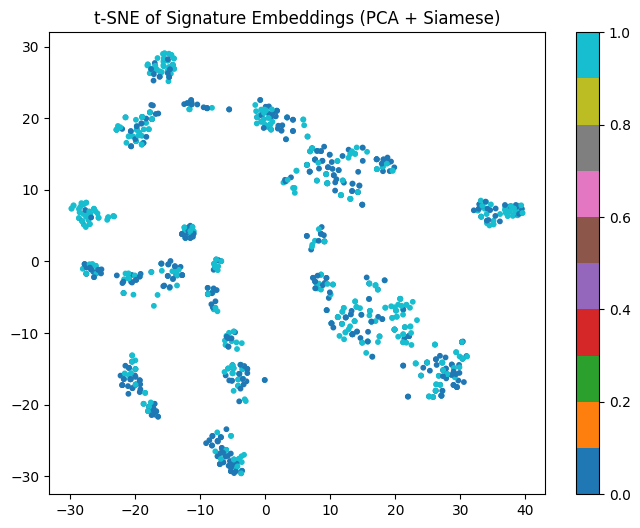

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# -------------------------
# Extract embeddings
# -------------------------
model.eval()
embeddings = []
all_labels = []

with torch.no_grad():
    for img1, img2, labels in test_loader:
        img1 = img1.to(device)
        emb = model.backbone(img1)
        embeddings.append(emb.cpu())
        all_labels.append(labels)

embeddings = torch.cat(embeddings).numpy()
all_labels = torch.cat(all_labels).numpy()

# -------------------------
# Reduce samples
# -------------------------
num_samples = 1000
indices = np.random.choice(len(embeddings), num_samples, replace=False)
embeddings = embeddings[indices]
all_labels = all_labels[indices]

# -------------------------
# PCA
# -------------------------
pca = PCA(n_components=50, random_state=42)
embeddings_pca = pca.fit_transform(embeddings)

# -------------------------
# t-SNE
# -------------------------
tsne = TSNE(n_components=2, perplexity=50, init="pca", random_state=42)
reduced = tsne.fit_transform(embeddings_pca)

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    reduced[:, 0],
    reduced[:, 1],
    c=all_labels,
    cmap="tab10",
    s=10
)
plt.title("t-SNE of Signature Embeddings (PCA + Siamese)")
plt.colorbar(scatter)
plt.show()